In [8]:
import random
import time

In [1]:
from chess_functions import nieuw_bord, toon_bord, geldige_zetten_pion, geldige_zetten_pion_aanv, geldige_zetten_paard
from chess_functions import geldige_zetten_loper, geldige_zetten_toren, geldige_zetten_koning, geldige_zetten_koningin

In [2]:
def doe_zet_simpel(bord, kleur, van, naar):

    van_rij = van[0]
    van_kol = van[1]

    naar_rij = naar[0]
    naar_kol = naar[1]

    volgend_bord = [rij[:] for rij in bord]

    if (bord[van_rij][van_kol][0] != kleur) or (bord[naar_rij][naar_kol][0] == kleur):
        print("Ongeldige zet!")

    else:
        function_name = f'geldige_zetten_{bord[van_rij][van_kol][1]}'
        function = globals().get(function_name)
        geldige_zetten = function(bord, kleur, van_rij, van_kol)
        
        if [naar_rij, naar_kol] in geldige_zetten:

            volgend_bord[naar_rij][naar_kol] = bord[van_rij][van_kol]
            volgend_bord[van_rij][van_kol] = ['leeg', 0]

        else:
            print('Ongeldige zet')
        
    return volgend_bord

In [3]:
def check(bord, kleur):

    found = False
    
    for i in range(8):
        for j in range(8):
            if bord[i][j] == [kleur, 'koning']:
                rij_k = i
                kol_k = j
                found = True
                break
        if found == True:
            break

    bedreigingen = []
    
    pot_bedr = geldige_zetten_pion_aanv(bord, kleur, rij_k, kol_k)
    for b in pot_bedr:
        if bord[b[0]][b[1]][1] == 'pion':
            bedreigingen.append(b)

    pot_bedr = geldige_zetten_paard(bord, kleur, rij_k, kol_k)
    for b in pot_bedr:
        if bord[b[0]][b[1]][1] == 'paard':
            bedreigingen.append(b)

    pot_bedr = geldige_zetten_toren(bord, kleur, rij_k, kol_k)
    for b in pot_bedr:
        if (bord[b[0]][b[1]][1] == 'toren') or (bord[b[0]][b[1]][1] == 'koningin'):
            bedreigingen.append(b)

    pot_bedr = geldige_zetten_loper(bord, kleur, rij_k, kol_k)
    for b in pot_bedr:
        if (bord[b[0]][b[1]][1] == 'loper') or (bord[b[0]][b[1]][1] == 'koningin'):
            bedreigingen.append(b)

    pot_bedr = geldige_zetten_koning(bord, kleur, rij_k, kol_k)
    for b in pot_bedr:
        if bord[b[0]][b[1]][1] == 'koning':
            bedreigingen.append(b)

    return bedreigingen

In [4]:
def alle_geldige_zetten(bord, kleur):
    
    zetten = []
    
    for i in range(8):
        for j in range(8):
            if bord[i][j][0] == kleur:
                
                if bord[i][j][1] == 'koning':
                    zetten_koning = geldige_zetten_koning(bord, kleur, i, j)
                    for zet in zetten_koning:
                        bord_v = doe_zet_simpel(bord, kleur, [i, j], zet)
                        check_v = check(bord_v, kleur)
                        if not check_v:
                            zetten.append([[i, j], zet])
                else:
                    function_name = f'geldige_zetten_{bord[i][j][1]}'
                    function = globals().get(function_name)
                    zetten_ander = function(bord, kleur, i, j)
                    for zet in zetten_ander:
                        zetten.append([[i, j], zet])
                        
    return zetten

In [5]:
def checkmate(bord, kleur):

    bedreigingen = check(bord, kleur)

    if not bedreigingen:
        return False, []

    else:
        zetten = alle_geldige_zetten(bord, kleur)
        oplossingen = []
        
        for z in zetten:
            bord_v = doe_zet_simpel(bord, kleur, z[0], z[1])
            bedr_v = check(bord_v, kleur)
            if not bedr_v:
                oplossingen.append(z)

        if oplossingen:
            return False, oplossingen
        else:
            return True, []

In [12]:
def spel_random_zetten(aantal_zetten):

    start = time.time()
    
    bord = nieuw_bord()
    #toon_bord(bord)

    for i in range(aantal_zetten):

        #time.sleep(3)

        zetten_wit = alle_geldige_zetten(bord, 'wit')

        if zetten_wit:
            zet_wit = random.choice(zetten_wit)
            bord = doe_zet_simpel(bord, 'wit', zet_wit[0], zet_wit[1])
        else:
            print(f'Wit kan geen geldige zet meer doen. Spel beëindigd na {2*i} zetten.')
            break

        #if (i+1) % 10 == 0: 
            #print(f'Zet {i+1}A:')
            #toon_bord(bord)

        #time.sleep(3)

        zetten_zwart = alle_geldige_zetten(bord, 'zwart')

        if zetten_zwart:
            zet_zwart = random.choice(zetten_zwart)
            bord = doe_zet_simpel(bord, 'zwart', zet_zwart[0], zet_zwart[1])
        else:
            print(f'Zwart kan geen geldige zet meer doen. Spel beëindigd na {2*i+1} zetten.')
            break

        #if (i+1) % 10 == 0: 
            #print(f'Zet {i+1}B:')
            #toon_bord(bord)

    stop = time.time()

    print(f'Game took {round(stop-start, 2)} seconds.')
    
    return bord

Zwart kan geen geldige zet meer doen. Spel beëindigd na 283 zetten.
Game took 0.03 seconds.


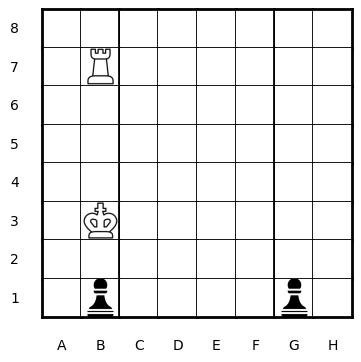

In [15]:
bord = spel_random_zetten(200)
toon_bord(bord)

In [18]:
def spel_random_zetten_tot_schaakmat(aantal_zetten):

    start = time.time()
    bord = nieuw_bord()

    for i in range(aantal_zetten):

        check_wit = check(bord, 'wit')
        zetten_wit = alle_geldige_zetten(bord, 'wit')

        if check_wit:
            checkmate_wit, oplossingen = checkmate(bord, 'wit')
            if checkmate_wit == True:
                print(f'Wit staat schaakmat. Spel beëindigd na {2*i} zetten.')
                break
            else:
                zet_wit = random.choice(oplossingen)
                bord = doe_zet_simpel(bord, 'wit', zet_wit[0], zet_wit[1])     
        elif zetten_wit:
            zet_wit = random.choice(zetten_wit)
            bord = doe_zet_simpel(bord, 'wit', zet_wit[0], zet_wit[1])
        else:
            print(f'Wit kan geen geldige zet meer doen. Spel beëindigd na {2*i} zetten.')
            break

        
        check_zwart = check(bord, 'zwart')
        zetten_zwart = alle_geldige_zetten(bord, 'zwart')

        if check_zwart:
            checkmate_zwart, oplossingen = checkmate(bord, 'zwart')
            if checkmate_zwart == True:
                print(f'Zwart staat schaakmat. Spel beëindigd na {2*i+1} zetten.')
                break
            else:
                zet_zwart = random.choice(oplossingen)
                bord = doe_zet_simpel(bord, 'zwart', zet_zwart[0], zet_zwart[1])
        elif zetten_zwart:
            zet_zwart = random.choice(zetten_zwart)
            bord = doe_zet_simpel(bord, 'zwart', zet_zwart[0], zet_zwart[1])
        else:
            print(f'Zwart kan geen geldige zet meer doen. Spel beëindigd na {2*i+1} zetten.')
            break

    stop = time.time()

    print(f'Game took {round(stop-start, 2)} seconds.')
    
    return bord

Wit kan geen geldige zet meer doen. Spel beëindigd na 218 zetten.
Game took 0.04 seconds.


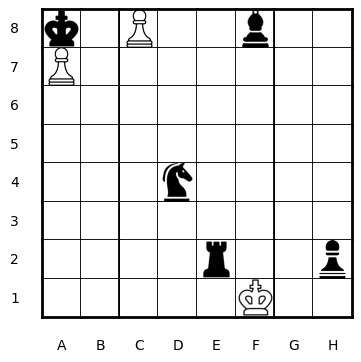

In [22]:
bord = spel_random_zetten_tot_schaakmat(3000)
toon_bord(bord)

In [23]:
class random_player:
    def __init__(self, kleur):
        self.strategy = """Always picks a random move from all available valid moves. 
        When checked, picks a random move from all valid moves that resolve the threat."""
        self.kleur = kleur
        self.status = 1
        
    def make_move(self, bord):
        ch = check(bord, self.kleur)
        zetten = alle_geldige_zetten(bord, self.kleur)

        if ch:
            ch_mt, oplossingen = checkmate(bord, self.kleur)
            if ch_mt == True:
                print(f'Spel beëindigd: {self.kleur} staat schaakmat.')
                self.status = 0
                return bord, self_status
            else:
                zet = random.choice(oplossingen)
                bord = doe_zet_simpel(bord, self.kleur, zet[0], zet[1]) 
                return bord, self.status
                
        elif zetten:
            zet = random.choice(zetten)
            bord = doe_zet_simpel(bord, self.kleur, zet[0], zet[1])
            return bord, self.status
            
        else:
            print(f'Spel beëindigd: {self.kleur} kan geen geldige zet meer uitvoeren.')
            self.status = 0
            return bord, self.status

In [24]:
def spel_random_zetten_tot_schaakmat_2(aantal_zetten):

    start = time.time()

    wit = random_player('wit')
    zwart = random_player('zwart')
    
    bord = nieuw_bord()

    for i in range(aantal_zetten):
        
        bord, status = wit.make_move(bord)
        if status == 0:
            break
        
        bord, status = zwart.make_move(bord)
        if status == 0:
            break

    stop = time.time()

    print(f'Game took {round(stop-start, 2)} seconds.')
    print('')
    toon_bord(bord)
    
    return bord

Game took 0.15 seconds.



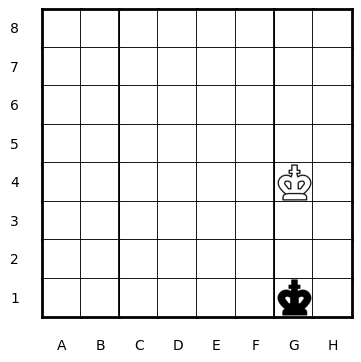

In [25]:
bord = spel_random_zetten_tot_schaakmat_2(1000)

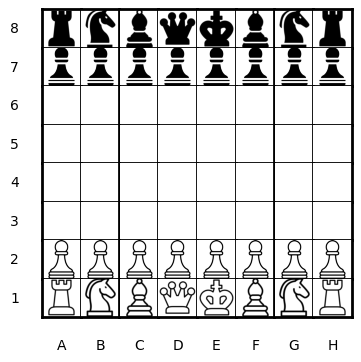

In [26]:
bord = nieuw_bord()
toon_bord(bord)

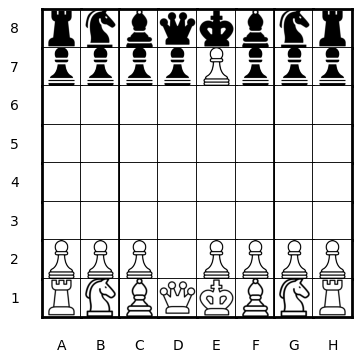

In [27]:
bord = doe_zet_simpel(bord, 'wit', [6, 3], [4,3])
bord = doe_zet_simpel(bord, 'wit', [4, 3], [3,3])
bord = doe_zet_simpel(bord, 'wit', [3, 3], [2,3])
bord = doe_zet_simpel(bord, 'wit', [2, 3], [1,4])

toon_bord(bord)

In [28]:
check(bord, 'zwart')

[]

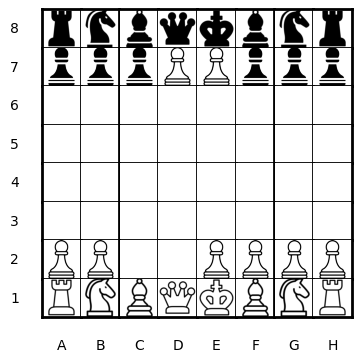

In [29]:
bord = doe_zet_simpel(bord, 'wit', [6, 2], [4,2])
bord = doe_zet_simpel(bord, 'wit', [4, 2], [3,2])
bord = doe_zet_simpel(bord, 'wit', [3, 2], [2,2])
bord = doe_zet_simpel(bord, 'wit', [2, 2], [1,3])

toon_bord(bord)

In [30]:
check(bord, 'zwart')

[[1, 3]]